In [16]:
### Project Based ExperimentQuiz
### NAME: TIMMAPURAM YOGEESWAR
### REGNO: 212223230233

In [17]:
!pip install pandas textblob matplotlib

In [18]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("/content/facebook_data.csv")

print("Facebook Data Loaded Successfully!")
print("Number of records:", len(df))

df.head()

Facebook Data Loaded Successfully!
Number of records: 30


,id,feedback
0,1,I absolutely love this product! It is amazing ...
1,2,The service was excellent and I am very happy.
2,3,This is the best experience I have ever had.
3,4,Amazing work! Keep it up.
4,5,I really enjoyed using this application.


In [20]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (30, 2)

Column Names:
['id', 'feedback']

Missing Values:
id          0
feedback    0
dtype: int64


In [21]:
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

df["polarity"] = df["feedback"].apply(get_polarity)

df.head()

,id,feedback,polarity
0,1,I absolutely love this product! It is amazing ...,0.538333
1,2,The service was excellent and I am very happy.,1.000000
2,3,This is the best experience I have ever had.,1.000000
3,4,Amazing work! Keep it up.,0.750000
4,5,I really enjoyed using this application.,0.500000


In [22]:
def get_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["polarity"].apply(get_sentiment)

df.head(10)

,id,feedback,polarity,sentiment
0,1,I absolutely love this product! It is amazing ...,0.538333,Positive
1,2,The service was excellent and I am very happy.,1.000000,Positive
2,3,This is the best experience I have ever had.,1.000000,Positive
3,4,Amazing work! Keep it up.,0.750000,Positive
4,5,I really enjoyed using this application.,0.500000,Positive
5,6,The product quality is excellent.,1.000000,Positive
6,7,Very useful and easy to use.,0.411667,Positive
7,8,I am extremely satisfied with the service.,0.500000,Positive
8,9,Fantastic experience! I will definitely recomm...,0.250000,Positive
9,10,The support team was very helpful and friendly.,0.287500,Positive


In [23]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
Positive    23
Negative     6
Neutral      1
Name: count, dtype: int64


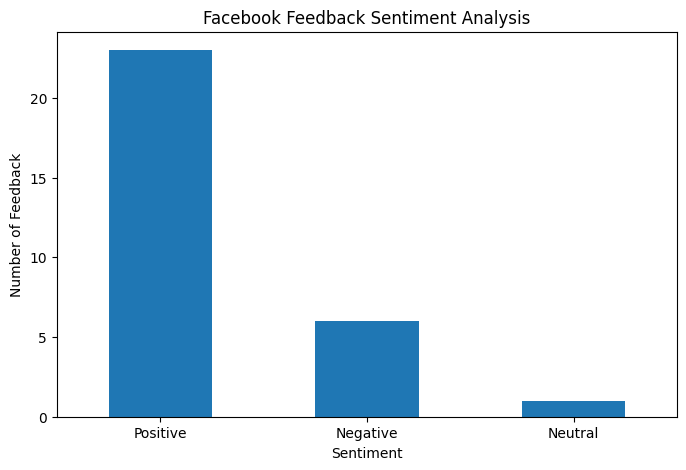

In [24]:
sentiment_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Facebook Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback")
plt.xticks(rotation=0)
plt.show()

In [25]:
positive_feedback = df[df["sentiment"] == "Positive"]

print("Total Positive Feedback:", len(positive_feedback))

positive_feedback

Total Positive Feedback: 23


,id,feedback,polarity,sentiment
0,1,I absolutely love this product! It is amazing ...,0.538333,Positive
1,2,The service was excellent and I am very happy.,1.000000,Positive
2,3,This is the best experience I have ever had.,1.000000,Positive
3,4,Amazing work! Keep it up.,0.750000,Positive
4,5,I really enjoyed using this application.,0.500000,Positive
5,6,The product quality is excellent.,1.000000,Positive
6,7,Very useful and easy to use.,0.411667,Positive
7,8,I am extremely satisfied with the service.,0.500000,Positive
8,9,Fantastic experience! I will definitely recomm...,0.250000,Positive
9,10,The support team was very helpful and friendly.,0.287500,Positive


In [26]:
positive_feedback.to_csv(
    "positive_feedback.csv",
    index=False
)

print("Positive feedback saved successfully!")

Positive feedback saved successfully!


In [27]:
positive_df = pd.read_csv("positive_feedback.csv")

positive_df.head()

,id,feedback,polarity,sentiment
0,1,I absolutely love this product! It is amazing ...,0.538333,Positive
1,2,The service was excellent and I am very happy.,1.000000,Positive
2,3,This is the best experience I have ever had.,1.000000,Positive
3,4,Amazing work! Keep it up.,0.750000,Positive
4,5,I really enjoyed using this application.,0.500000,Positive


In [28]:
print("Number of positive feedback:", len(positive_df))

Number of positive feedback: 23


In [29]:
print(positive_df)

    id                                           feedback  polarity sentiment
0    1  I absolutely love this product! It is amazing ...  0.538333  Positive
1    2     The service was excellent and I am very happy.  1.000000  Positive
2    3       This is the best experience I have ever had.  1.000000  Positive
3    4                          Amazing work! Keep it up.  0.750000  Positive
4    5           I really enjoyed using this application.  0.500000  Positive
5    6                  The product quality is excellent.  1.000000  Positive
6    7                       Very useful and easy to use.  0.411667  Positive
7    8         I am extremely satisfied with the service.  0.500000  Positive
8    9  Fantastic experience! I will definitely recomm...  0.250000  Positive
9   10    The support team was very helpful and friendly.  0.287500  Positive
10  14        The application is okay and works normally.  0.325000  Positive
11  15         Nothing special, it is an average product.  0.103